# Julia's fractal generator algorithm

__Julia sets are sets of points in the complex plane that form intricate geometric patterns. They are generated by the recursive iteration of a function, typically $f(z) = z^2 + c$.__

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import time as tm

### Principal Algorithm

In [74]:
def recursiveJulia(z, c, iteration, max_iter):
    
    if abs(z) > 2:
        return iteration
    
    if iteration >= max_iter:
        return max_iter
    
    new_z = z * z + c
    
    return recursiveJulia(new_z, c, iteration + 1, max_iter)

# test
recursiveJulia(0+0j, -0.7+0.27015j, 0, 10)

10

### Results generator functions

In [75]:
def resultsGenerator(width, height, realC, imagC, maxIter):
    x = np.linspace(-2, 2, width)
    y = np.linspace(-2, 2, height)

    results = np.zeros((height, width))

    c = complex(realC, imagC)

    t0 = tm.time()
    for i in range(height):
        for j in range(width):
            
            real = x[j]
            imag = y[i]
            
            z = complex(real, imag)
            
            results[i, j] = recursiveJulia(z, c, 0, maxIter)
    t1 = tm.time()
    totalTime = t1 - t0        
    
    return results, totalTime

results, time = resultsGenerator(1000, 1000, -0.7, 0.27015, 500)

### 2D drawing example

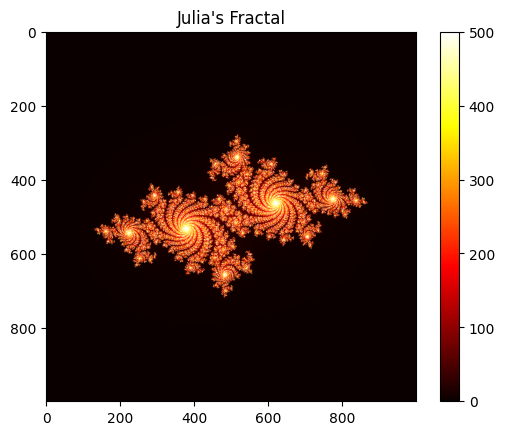

4.793288230895996


In [76]:
plt.imshow(results, cmap='hot')
plt.colorbar()
plt.title("Julia's Fractal")
plt.show()

print(time)

### Comparison of times with different inputs (max iter)

In [78]:
max_iters = [10, 20, 50, 100, 150, 300, 400, 500, 1000]
times = []
for max_iter in max_iters:
    results, finishTime = resultsGenerator(1000, 1000, -0.7, 0.27015, max_iter)
    times.append(finishTime)
    
print(times)

[0.6450979709625244, 0.764611005783081, 1.1124987602233887, 1.968740701675415, 2.6153111457824707, 4.077253818511963, 4.526161432266235, 4.988544702529907, 5.4309241771698]
